## Calculo de los índices de ENSO utilizando datos de ERA5 y comparando con los publicados por la NOAA


**Objetivo.** Calcular tres índices usados para describir ENSO a partir de SST y presión media a nivel del mar (MSLP) de ERA5.


**Índices a calcular:** 
- ONI
- RONI
- SOI

**Datos a utilizar:** 
- Presión media a nivel del mar (MSLP) y temperatura superficial del mar (SST) a (1^\circ\)
- Índices calculados por la NOAA a partir de datos de *ERSSTv6*


Fuentes NOAA/CPC:
- ONI: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/oni/v6/
- RONI: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/
- SOI: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensocycle/soi.shtml
- Datos de índices: https://www.cpc.ncep.noaa.gov/data/indices/

**Datos de esta versión:** ERA5 mensual, enero de 1950–diciembre de 2025, malla global degradada a $1^\circ$ a partir de datos a $0.25^\circ$, variables `sst` y `msl`.

## Definición de los índices

### ONI - Oceanic Niño Index

Describe las anomalías de SST en la región Niño 3.4:

$$
5^\circ S-5^\circ N,\qquad 170^\circ W-120^\circ W.
$$

En esta práctica:

$$
T'_{3.4}(t)=T_{3.4}(t)-\overline{T}_{3.4,m}^{1991-2020}
$$

y definimos el índice de tres meses como

$$
ONI_{ERA5}(t)=\frac{T'_{3.4}(t-1)+T'_{3.4}(t)+T'_{3.4}(t+1)}{3}.
$$

### RONI - Relative Oceanic Niño Index

Intenta separar la anomalía ENSO de cambios comunes a todo el cinturón tropical:

$$
T'_{rel}=T'_{3.4}-T'_{trop},
$$

donde $T'_{trop}$ es la anomalía media de SST entre $20^\circ S$ y $20^\circ N$.

Después se ajusta la amplitud para que la varianza sea comparable con la del índice Niño 3.4 original.

### SOI - Southern Oscillation Index

Describe la componente atmosférica de ENSO mediante el contraste de presión entre **Tahiti** y **Darwin**:

$$
SOI \propto P'_{Tahiti}-P'_{Darwin}.
$$

Valores negativos persistentes suelen asociarse con El Niño y positivos con La Niña.


In [ ]:
# Cargamos las librerias necesarias

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# ARCHIVOS CON DATOS ERA5
# ---------------------------------------------------------
SST_FILE  = "era5_sst_1950_2025_1deg.nc"
MSLP_FILE = "era5_msl_1950_2025_1deg.nc"


In [18]:
#Inspeccionamos los metadatos
ds = xr.open_dataset(SST_FILE); print(ds); ds.close()

<xarray.Dataset>
Dimensions:     (valid_time: 912, lon: 360, lat: 180)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
  * lon         (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat         (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    sst         (valid_time, lat, lon) float32 ...
Attributes:
    CDI:                       Climate Data Interface version 2.1.1 (https://...
    Conventions:               CF-1.7
    institution:               European Centre for Medium-Range Weather Forec...
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    history:                   Sun Oct 04 22:35:50 2026: cdo -P 4 remapcon,r3...
    CDO:                       Climate Data Operators version 2.1.1 (https://...
    cdo_openmp_thread_number:  4


In [19]:
#Revisamos los atributos de la variable
ds = xr.open_dataset(SST_FILE); print(ds.sst); ds.close()

<xarray.DataArray 'sst' (valid_time: 912, lat: 180, lon: 360)>
[59097600 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
  * lon         (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat         (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes: (12/21)
    standard_name:                            unknown
    long_name:                                Sea surface temperature
    units:                                    K
    GRIB_dataType:                            an
    GRIB_typeOfLevel:                         surface
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Sea surface temperature
    GRIB_shortName:                           sst
    GRIB_un

In [20]:
#Inspeccionamos los metadatos
ds = xr.open_dataset(MSLP_FILE); print(ds); ds.close()

<xarray.Dataset>
Dimensions:     (valid_time: 912, lon: 360, lat: 180)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
  * lon         (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat         (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    msl         (valid_time, lat, lon) float32 ...
Attributes:
    CDI:                       Climate Data Interface version 2.1.1 (https://...
    Conventions:               CF-1.7
    institution:               European Centre for Medium-Range Weather Forec...
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    history:                   Mon Oct 05 09:29:59 2026: cdo -P 4 remapcon,r3...
    CDO:                       Climate Data Operators version 2.1.1 (https://...
    cdo_openmp_thread_number:  4


In [ ]:
#Revisamos los atributos de la variable
ds = xr.open_dataset(MSLP_FILE); print(ds.msl); ds.close()

<xarray.DataArray 'msl' (valid_time: 912, lat: 180, lon: 360)>
[59097600 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
  * lon         (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat         (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes: (12/21)
    standard_name:                            air_pressure_at_mean_sea_level
    long_name:                                Mean sea level pressure
    units:                                    Pa
    GRIB_dataType:                            an
    GRIB_typeOfLevel:                         surface
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Mean sea level pressure
    GRIB_shortName:                  

In [ ]:
# A partir de la inspección inicial de los archivos podemos definir los nombres 
# de las variables a utilizar.
SST_VAR  = "sst"
MSLP_VAR = "msl"

# Datos mensuales: enero 1950–diciembre 2025, malla 1°
# Coordenadas: valid_time, lat, lon (0–359°E)

# Definimos el periodo de la climatología
BASE_START = 1991
BASE_END   = 2020


In [84]:
#Definimos algunas funciones 

def prom_area(da, lat_min, lat_max, lon_min, lon_max):
    """Promedio espacial ponderado por cos(lat). Longitudes en 0-360."""
    region = da.sel(
        lat=slice(min(lat_min, lat_max), max(lat_min, lat_max)),
        lon=slice(lon_min, lon_max)
    )

    if region.sizes.get("lat", 0) == 0 or region.sizes.get("lon", 0) == 0:
        raise ValueError("La selección espacial quedó vacía.")

    weights = np.cos(np.deg2rad(region["lat"]))
    return region.weighted(weights).mean(("lat", "lon"))


def anom_mens(series, timename, start=1991, end=2020):
    time_slice = slice(f"{start}-01-01", f"{end}-12-31")
    base = series.sel({timename:time_slice})
    clim = base.groupby  (f"{timename}.month").mean(timename)
    return series.groupby(f"{timename}.month") - clim


def zscore_mens(series, timename, start=1991, end=2020):
    time_slice = slice(f"{start}-01-01", f"{end}-12-31")
    base = series.sel({timename:time_slice})
    clim = base.groupby(f"{timename}.month").mean(timename)
    std = base.groupby(f"{timename}.month").std(timename)
    anom = series.groupby(f"{timename}.month") - clim
    return anom.groupby(F"{timename}.month") / std

def vista_prev(ds, varname, time,lonname,latname, timename):
    """
    Vista previa rápida de una variable de un Dataset de xarray.

    ds : xarray.Dataset
        Dataset que contiene la variable.
        
    varname : str
        Nombre de la variable a visualizar.
        
    time : str o datetime
        Fecha deseada. Ejemplo: "1997-12-01".

    Returns
    -------
    field : xarray.DataArray
        Campo 2D seleccionado.
    """
    da = ds[varname]


    # -----------------------------------------------------
    # Seleccionar fecha más cercana
    # -----------------------------------------------------
    field = da.sel(
        {timename: time},
        method="nearest"
    )

    selected_time = field[timename].values

    # -----------------------------------------------------
    # Conversión de unidades para visualización
    # -----------------------------------------------------
    #units = str(field.attrs.get("units", "")).lower()
    plot_units = field.attrs.get("units", "")

    # -----------------------------------------------------
    # Estadísticos rápidos
    # -----------------------------------------------------
    print(f"Variable : {varname}")
    print(f"Fecha solicitada : {time}")
    print(f"Fecha utilizada  : {np.datetime_as_string(selected_time, unit='D')}")
    print(f"Unidades : {plot_units}")
    print()
    print(f"Mínimo : {float(field.min(skipna=True)):.2f}")
    print(f"Media  : {float(field.mean(skipna=True)):.2f}")
    print(f"Máximo : {float(field.max(skipna=True)):.2f}")

    # -----------------------------------------------------
    # Figura
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 5))

    field.plot(
        ax=ax,
        x="lon",
        y="lat",
        robust=True,
        cbar_kwargs={
            "label": f"{varname} ({plot_units})"
        }
    )

    ax.set_title(
        f"{varname.upper()} — "
        f"{np.datetime_as_string(selected_time, unit='D')}"
    )

    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    plt.tight_layout()
    plt.show()

    #return field

In [21]:
ds = xr.open_dataset(MSLP_FILE)

Variable : msl
Fecha solicitada : 2021-06-15
Fecha utilizada  : 2021-06-01
Unidades : Pa

Mínimo : 97212.16
Media  : 100882.39
Máximo : 102625.20


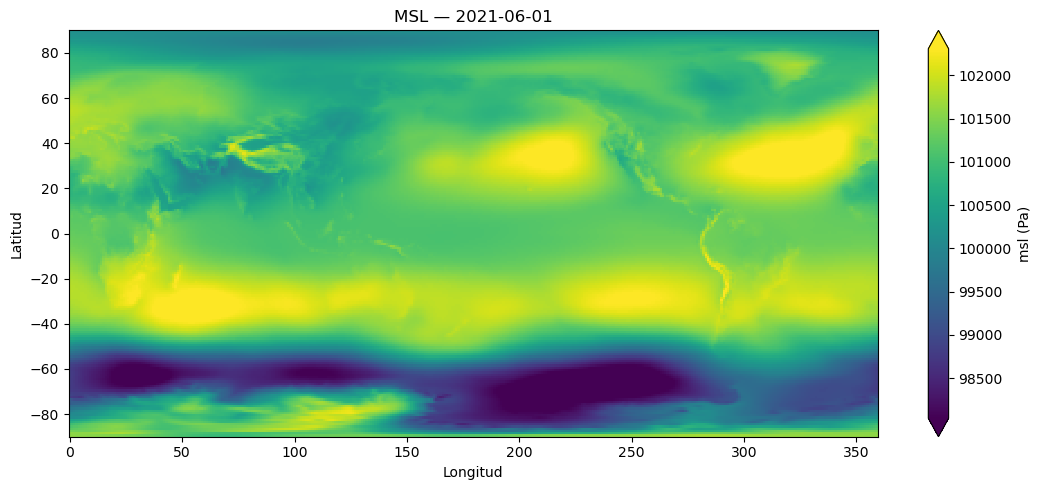

In [ ]:
#De la inspección de los archivos y las variables sabemos que para
#presión el nombre es msl y esta en Pa.
vista_prev(ds, "msl", "2021-06-15","lon","lat", "valid_time")
ds.close()

In [54]:
#Cargamos los datos a utilizar

ds_sst = xr.open_dataset(SST_FILE)
ds_mslp = xr.open_dataset(MSLP_FILE)

#Extraemos las variables
sst = ds_sst["sst"]
mslp = ds_mslp["msl"]

#Sabemos que SST está en K y mslp en Pa 
#Convertimos a C y hPa

sst = sst - 273.15
sst.attrs["units"] = "degC"

mslp = mslp/100.0
mslp.attrs["units"] = "hPa"

#Revisamos los metadatos para las dos variables
print("SST:")
print(sst)
print("\nMSLP:")
print(mslp)

#De la primera inspección sabemos que el tiempo esta en la variable "valid_time"
#Imprimimos el periodo que tenemos de información

print("\nPeriodo SST :", str(sst.valid_time.values[0])[:10], "a", str(sst.valid_time.values[-1])[:10])
print("Periodo MSLP:", str(mslp.valid_time.values[0])[:10], "a", str(mslp.valid_time.values[-1])[:10])

SST:
<xarray.DataArray 'sst' (valid_time: 912, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6902771, -1.6902771, -1.6902771, ..., -1.6902771,
         -1.6902771, -1.6902771],
        [-1.6902771, -1.6902771, -1.6902771, ..., -1.6902771,
         -1.6902771, -1.6902771],
        [-1.6902771, -1.6902771, -1.6902771, ..., -1.6902771,
         -1.6902771, -1.6902771]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.689148 , -1.689148 , -1.6890564, ...,

## Cálculo de ONI

El área utilizada para ONI es:

$$
5^\circ S-5^\circ N,\qquad
170^\circ W-120^\circ W
$$

que en longitudes $0-360^\circ$ equivale a

$$
190^\circ E-240^\circ E.
$$

### Procedimiento

1. Calculamos la climatología de SST para la region
2. Calculamos la anomalía mensual 
3. Media móvil centrada de tres meses.

In [55]:
#Cálculamos la climatología
n34_sst = prom_area(
    sst,
    lat_min=-5,
    lat_max=5,
    lon_min=190,
    lon_max=240
)

n34_sst

<xarray.DataArray 'sst' (valid_time: 912)>
array([25.62797834, 25.66412476, 26.33784722, 26.83461356, 27.23216115,
       27.13834541, 26.54293746, 26.12967997, 25.52517866, 25.80483297,
       25.72342463, 25.97600802, 25.61031062, 26.29127689, 26.69264045,
       27.7944534 , 28.51773789, 28.11714441, 28.71142265, 27.76303458,
       27.16745375, 27.69157678, 27.88952437, 27.93913767, 27.53680319,
       27.63725432, 27.56714593, 28.4413755 , 27.98589502, 27.32746197,
       26.93095557, 26.55624067, 26.2338985 , 26.42267683, 26.52260272,
       26.87547788, 27.1279706 , 27.24275801, 27.66587231, 28.24961771,
       28.78336221, 28.20514923, 27.91416887, 27.41265247, 27.60751019,
       27.13128156, 26.66396183, 26.59307769, 27.01088793, 26.80463096,
       27.01326612, 27.08183536, 27.17341345, 27.04422092, 26.26513018,
       26.09475816, 25.51700039, 25.74771736, 25.65284514, 25.50460471,
       25.40206258, 25.88227901, 26.5046908 , 26.60249981, 27.08999261,
       26.64547642, 26.39609381, 25.81365449, 25.26549531, 24.60099922,
       24.49599134, 24.71592202, 25.44015926, 25.64806703, 26.30121342,
       27.0204035 , 26.68575772, 26.72186996, 26.42881446, 26.06358369,
       25.79693924, 25.63320691, 25.67157209, 25.75113529, 26.04112884,
       26.62667602, 27.68167569, 28.15890491, 29.15703459, 28.71841847,
       28.21984279, 27.73865058, 27.65173984, 27.53542582, 27.55784342,
       27.48701914, 28.17261293, 27.94363782, 28.18135033, 28.29593881,
...
       25.64905677, 25.77829165, 25.96163043, 26.42352481, 27.2357716 ,
       27.67196643, 27.84344192, 27.55149011, 27.03157819, 26.9759869 ,
       27.44228584, 27.4933205 , 27.35815071, 27.09816038, 27.30281114,
       28.0777468 , 28.4421334 , 28.55693766, 28.2343439 , 27.63891204,
       26.81756472, 26.55496867, 27.1558874 , 27.14700534, 26.96356622,
       27.00128186, 27.04182568, 27.59858246, 28.1099605 , 27.52195157,
       27.23016982, 27.00745116, 26.18126286, 25.75830832, 25.34662875,
       25.275998  , 25.4295174 , 25.52419247, 25.88301471, 26.63416235,
       27.2115378 , 27.51950126, 27.58073961, 27.04164154, 26.44432803,
       26.26200354, 25.74468187, 25.74345957, 25.56851216, 25.65349615,
       25.91374992, 26.15780055, 26.67662534, 26.76058764, 26.97986925,
       26.6291084 , 25.92956998, 25.74199805, 25.78723407, 25.6742097 ,
       25.68610286, 25.81418468, 26.21625711, 27.20050439, 27.9308723 ,
       28.37707932, 28.61952078, 28.36898874, 28.22265476, 28.33092776,
       28.35145305, 28.56182846, 28.57649298, 28.33112577, 28.28157422,
       28.51386537, 28.68918632, 28.12723562, 27.97141323, 27.39222293,
       26.84974791, 26.35241447, 26.1914821 , 26.44075037, 25.83993357,
       25.70444681, 26.2436679 , 27.27167503, 27.66240129, 27.82355049,
       27.6542148 , 27.12714778, 26.50097009, 26.23186866, 26.14097066,
       26.00348495, 25.91022922])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01

In [65]:
#Calculamos las anomalías mensuales respecto a una climatología (1991-2020)

n34_anom = anom_mens(
    n34_sst,
    "valid_time",
    BASE_START,
    BASE_END
)

n34_anom

<xarray.DataArray 'sst' (valid_time: 912)>
array([-0.86988008, -1.00709965, -0.85851528, -0.96845628, -0.64487893,
       -0.59112545, -0.76692253, -0.70280115, -1.16326599, -0.90533902,
       -0.99607961, -0.58691558, -0.8875478 , -0.37994751, -0.50372205,
       -0.00861643,  0.6406978 ,  0.38767355,  1.40156266,  0.93055346,
        0.4790091 ,  0.98140479,  1.17002012,  1.37621407,  1.03894477,
        0.96602991,  0.37078343,  0.63830566,  0.10885493, -0.40200888,
       -0.37890442, -0.27624045, -0.45454615, -0.28749517, -0.19690152,
        0.31255428,  0.63011218,  0.5715336 ,  0.46950981,  0.44654787,
        0.90632212,  0.47567838,  0.60430888,  0.58017136,  0.91906553,
        0.42110956, -0.05554242,  0.0301541 ,  0.51302951,  0.13340655,
       -0.18309638, -0.72123448, -0.70362664, -0.68524994, -1.04472981,
       -0.73772296, -1.17144427, -0.96245464, -1.0666591 , -1.05831889,
       -1.09579584, -0.7889454 , -0.6916717 , -1.20057003, -0.78704748,
       -1.08399444, -0.91376618, -1.01882663, -1.42294934, -2.10917277,
       -2.22351291, -1.84700158, -1.05769916, -1.02315738, -0.89514909,
       -0.78266634, -1.19128237, -1.0076009 , -0.88104552, -0.76889743,
       -0.89150542, -1.07696508, -1.04793215, -0.8117883 , -0.45672958,
       -0.04454838,  0.48531319,  0.35583507,  1.2799945 ,  0.98894761,
        0.9099828 ,  0.90616947,  0.96329519,  0.82525383,  0.83833918,
        0.92409555,  1.67475451,  1.27241342,  0.98498783,  0.49286897,
...
       -0.91386682, -0.71956677, -0.70959398, -0.77283769, -0.56729823,
       -0.20507366,  0.11397106,  0.24163012,  0.19909707,  0.28754225,
        0.73211385,  0.77381625,  0.79522711,  0.60030196,  0.63158673,
        0.88138429,  0.63906357,  0.67989757,  0.50487304,  0.32905205,
       -0.0149164 , -0.13347598,  0.44571541,  0.4275011 ,  0.40064262,
        0.50342345,  0.37060127,  0.40221996,  0.30689066, -0.35508852,
       -0.49930104, -0.30240883, -0.65121825, -0.93013633, -1.36354324,
       -1.44350624, -1.1334062 , -0.97366595, -0.7882097 , -0.56220015,
       -0.59153204, -0.35753883, -0.14873125, -0.26821845, -0.38815309,
       -0.42644111, -0.96549012, -0.97604468, -0.99441144, -0.84436227,
       -0.75747449, -1.03856195, -1.12644449, -1.11645245, -0.7496016 ,
       -0.68075159, -0.90291114, -0.9464466 , -0.92293793, -1.04529454,
       -0.87682074, -0.68367374, -0.45496729,  0.00414189,  0.12780246,
        0.50003923,  0.89004992,  1.05912875,  1.39017364,  1.6424831 ,
        1.64128106,  1.84232421,  2.01356939,  1.83326735,  1.61034981,
        1.31750286,  0.88611648,  0.25019553,  0.24194237,  0.08236294,
        0.0172668 , -0.33603018, -0.51868989, -0.27875387, -0.72299003,
       -0.7934116 , -0.42755651,  0.07531252, -0.14066855, -0.0534896 ,
       -0.07525606, -0.18271221, -0.33151103, -0.45657599, -0.56920134,
       -0.71601929, -0.65269438])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
    month       (valid_time) int64 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12

In [ ]:
#Calculamos el promedio móvil centrado para obtener ONI
#Utilizamos la rutina rolling para hacer este promedio

oni_era5 = n34_anom.rolling(
    valid_time=3,
    center=True
).mean()

oni_era5.name = "ONI_ERA5"

oni_era5

<xarray.DataArray 'ONI_ERA5' (valid_time: 912)>
array([            nan, -9.11831672e-01, -9.44690404e-01, -8.23950165e-01,
       -7.34820222e-01, -6.67642304e-01, -6.86949709e-01, -8.77663221e-01,
       -9.23802053e-01, -1.02156154e+00, -8.29444737e-01, -8.23514330e-01,
       -6.18136964e-01, -5.90405789e-01, -2.97428667e-01,  4.27864369e-02,
        3.39918305e-01,  8.09978002e-01,  9.06596557e-01,  9.37041740e-01,
        7.96989117e-01,  8.76811337e-01,  1.17587966e+00,  1.19505965e+00,
        1.12706292e+00,  7.91919370e-01,  6.58372999e-01,  3.72648005e-01,
        1.15050568e-01, -2.24019460e-01, -3.52384585e-01, -3.69897007e-01,
       -3.39427255e-01, -3.12980947e-01, -5.72808034e-02,  2.48588312e-01,
        5.04733352e-01,  5.57051861e-01,  4.95863757e-01,  6.07459931e-01,
        6.09516121e-01,  6.62103124e-01,  5.53386204e-01,  7.01181923e-01,
        6.40115485e-01,  4.28210894e-01,  1.31907081e-01,  1.62547063e-01,
        2.25530053e-01,  1.54446560e-01, -2.56974767e-01, -5.35985831e-01,
       -7.03370350e-01, -8.11202127e-01, -8.22567568e-01, -9.84632344e-01,
       -9.57207288e-01, -1.06685267e+00, -1.02914421e+00, -1.07359127e+00,
       -9.81020040e-01, -8.58804312e-01, -8.93729041e-01, -8.93096402e-01,
       -1.02387065e+00, -9.28269365e-01, -1.00552908e+00, -1.11851405e+00,
       -1.51698292e+00, -1.91854501e+00, -2.05989575e+00, -1.70940455e+00,
       -1.30928604e+00, -9.92001874e-01, -9.00324268e-01, -9.56365931e-01,
       -9.93849869e-01, -1.02664293e+00, -8.85847952e-01, -8.47149457e-01,
...
        6.07944726e-01,  5.04607553e-01,  2.73002896e-01,  6.02198885e-02,
        9.91076767e-02,  2.46580175e-01,  4.24619711e-01,  4.43855723e-01,
        4.24889113e-01,  4.25414891e-01,  3.59903962e-01,  1.18007365e-01,
       -1.82499634e-01, -3.85599463e-01, -4.84309374e-01, -6.27921138e-01,
       -9.81632610e-01, -1.24572860e+00, -1.31348523e+00, -1.18352613e+00,
       -9.65093950e-01, -7.74691934e-01, -6.47313965e-01, -5.03757008e-01,
       -3.65934042e-01, -2.58162845e-01, -2.68367597e-01, -3.60937551e-01,
       -5.93361442e-01, -7.89325305e-01, -9.78648745e-01, -9.38272795e-01,
       -8.65416067e-01, -8.80132905e-01, -9.74160312e-01, -1.09381963e+00,
       -9.97499517e-01, -8.48935214e-01, -7.77754776e-01, -8.43369774e-01,
       -9.24098555e-01, -9.71559691e-01, -9.48351071e-01, -8.68596342e-01,
       -6.71820592e-01, -3.78166382e-01, -1.07674315e-01,  2.10661192e-01,
        5.05963870e-01,  8.16405966e-01,  1.11311744e+00,  1.36392850e+00,
        1.55797927e+00,  1.70869613e+00,  1.83239155e+00,  1.89638699e+00,
        1.81906218e+00,  1.58704001e+00,  1.27132305e+00,  8.17938292e-01,
        4.59418128e-01,  1.91500281e-01,  1.13857369e-01, -7.88001488e-02,
       -2.79151092e-01, -3.77824648e-01, -5.06811264e-01, -5.98385168e-01,
       -6.47986048e-01, -3.81885196e-01, -1.64304177e-01, -3.96152072e-02,
       -8.98047361e-02, -1.03819289e-01, -1.96493098e-01, -3.23599742e-01,
       -4.52429453e-01, -5.80598874e-01, -6.45971668e-01,             nan])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
    month       (valid_time) int64 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12

In [ ]:
# Tiempo inicial de las gráficas
PLOT_START = "1980-01-01"
PLOT_END   = None

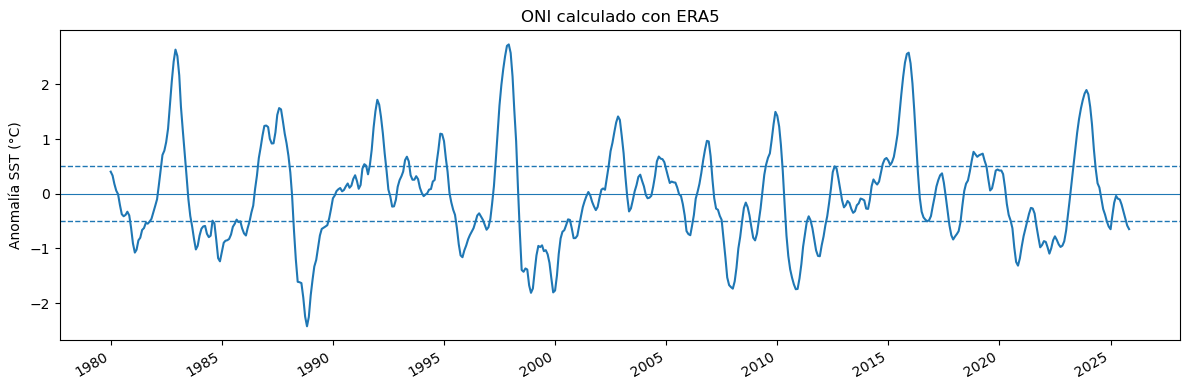

In [ ]:
#Generamos una gráfica para inspeccionar nuestro índice

fig, ax = plt.subplots(figsize=(12, 4))

oni_era5.sel(valid_time=slice(PLOT_START, PLOT_END)).plot(ax=ax)

ax.axhline(0.5, ls="--", lw=1)
ax.axhline(-0.5, ls="--", lw=1)
ax.axhline(0, lw=0.8)

ax.set_title("ONI calculado con ERA5")
ax.set_ylabel("Anomalía SST (°C)")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

### ¿Qué estamos haciendo a la hora de hacer el promedio móvil centrado en 3 meses?
### ------------------------------------------------------------------------------------------------------------------------------------------------

## Cálculo del RONI

La NOAA define el *RONI* mediante el cálculo de la anomalía del niño 3.4 menos la anomalía promedio del SST del cinturón tropical 
definido entre $20^\circ S-20^\circ N$ de la siguiente manera:

$$
T'_{rel}=T'_{3.4}-T'_{20S-20N}
$$

Una vez hecho el calculo se ajusta la amplitud de la serie para que la variabilidad sea comparable con el índice del niño 3.4

Para el ajuste de la variabilidad, para próposito de la práctica ese ajuste de amplitud se hará a partir de la desviación estándar del indice de tres meses para nuestro periodo climatológico 1991-2020.


In [61]:
#Calculamos la temperatura promedio para el cinturon tropical

trop_sst = prom_area(
sst,
    lat_min=-20,
    lat_max=20,
    lon_min=0,
    lon_max=360
)

trop_sst

<xarray.DataArray 'sst' (valid_time: 912)>
array([26.72802716, 26.9440048 , 27.16105142, 27.51034113, 27.32370265,
       26.92747662, 26.40053637, 26.25309636, 26.28417257, 26.62059596,
       26.64235993, 26.65194502, 26.62211903, 26.8582731 , 26.99969831,
       27.47767732, 27.53810221, 27.16719427, 26.77612706, 26.64972617,
       26.64599278, 27.01550618, 27.1677522 , 27.10661683, 27.08570643,
       27.26885635, 27.47256532, 27.79901786, 27.67036436, 27.16999234,
       26.69094968, 26.43722266, 26.53727277, 26.73560659, 26.94395318,
       26.94819432, 26.99841487, 27.17240708, 27.48134974, 27.77911892,
       27.61647417, 27.20848206, 26.7846315 , 26.61036388, 26.67279089,
       26.90254042, 26.96277036, 26.93674231, 26.95563991, 27.07403784,
       27.29117382, 27.57222009, 27.36493688, 26.90395117, 26.38753867,
       26.20595235, 26.23580832, 26.40032189, 26.58345976, 26.46468135,
       26.62478197, 26.74541354, 27.02343883, 27.30146835, 27.17648179,
       26.6796423 , 26.39337132, 26.16653231, 26.24893293, 26.36225506,
       26.54694324, 26.45844446, 26.5272081 , 26.70308562, 26.97934801,
       27.36792355, 27.11071299, 26.68729893, 26.28481757, 26.18052788,
       26.15050308, 26.44376078, 26.63325211, 26.68352697, 26.7449903 ,
       26.99713496, 27.3668201 , 27.67074944, 27.72234358, 27.22931638,
       26.83483781, 26.56248302, 26.6105353 , 26.90324313, 27.08290601,
       27.08684079, 27.17631805, 27.40718412, 27.58032572, 27.88882631,
...
       27.1296776 , 27.05756766, 27.22102082, 27.54748828, 27.84917631,
       27.81953479, 27.36961605, 26.92471423, 26.76297668, 26.9320174 ,
       27.29357579, 27.44276787, 27.4154942 , 27.34466134, 27.53886452,
       27.87713055, 28.16310626, 28.10343258, 27.67267278, 27.19319252,
       26.89799388, 26.95485975, 27.32912875, 27.54053082, 27.56628611,
       27.5535026 , 27.65620394, 28.01044032, 28.2939429 , 28.1124858 ,
       27.62903825, 27.18782795, 26.92243972, 26.94449566, 27.12271218,
       27.21530784, 27.15349134, 27.09562162, 27.22770239, 27.60690304,
       27.86915077, 27.83196991, 27.48815389, 27.10946688, 26.9435079 ,
       26.99081906, 27.18173519, 27.28478861, 27.17391256, 27.22454857,
       27.30950511, 27.62333638, 27.84015366, 27.70451649, 27.37020277,
       26.85071903, 26.69355602, 26.78803816, 27.00306536, 27.15609162,
       27.15699071, 27.12248568, 27.30527479, 27.81052509, 28.25293052,
       28.24839699, 27.90724997, 27.47322182, 27.35329286, 27.48424882,
       27.74617761, 27.92914287, 27.98995872, 28.04226705, 28.15384959,
       28.3895643 , 28.61351739, 28.44364374, 27.92842703, 27.39494402,
       27.18922907, 27.25413738, 27.4998914 , 27.62949001, 27.43576444,
       27.43803583, 27.60223012, 27.98519044, 28.1839387 , 28.09742658,
       27.58846879, 27.13278241, 26.95788668, 27.02503701, 27.24470704,
       27.30660748, 27.30319088])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01

In [70]:
# Anomalías mensuales con la misma climatología
trop_anom = anom_mens(
    trop_sst,
    "valid_time",
    BASE_START,
    BASE_END
)

trop_anom

<xarray.DataArray 'sst' (valid_time: 912)>
array([-0.41142851, -0.3674983 , -0.49331869, -0.40614697, -0.50262431,
       -0.47509482, -0.54344445, -0.48573258, -0.55764374, -0.45735169,
       -0.57850171, -0.52842395, -0.51733664, -0.45323   , -0.6546718 ,
       -0.43881079, -0.28822475, -0.23537717, -0.16785377, -0.08910277,
       -0.19582354, -0.06244146, -0.05310943, -0.07375214, -0.05374924,
       -0.04264675, -0.18180479, -0.11747024, -0.15596261, -0.2325791 ,
       -0.25303114, -0.30160628, -0.30454355, -0.34234105, -0.27690846,
       -0.23217465, -0.1410408 , -0.13909601, -0.17302037, -0.13736918,
       -0.20985279, -0.19408937, -0.15934933, -0.12846506, -0.16902542,
       -0.17540722, -0.25809127, -0.24362666, -0.18381576, -0.23746526,
       -0.36319629, -0.34426801, -0.46139008, -0.49862027, -0.55644216,
       -0.53287659, -0.60600799, -0.67762575, -0.63740187, -0.71568762,
       -0.5146737 , -0.56608956, -0.63093128, -0.61501975, -0.64984517,
       -0.72292913, -0.5506095 , -0.57229663, -0.59288338, -0.71569258,
       -0.6739184 , -0.72192451, -0.61224757, -0.60841748, -0.6750221 ,
       -0.54856455, -0.71561397, -0.71527251, -0.65916325, -0.55830106,
       -0.69131324, -0.63418686, -0.58760953, -0.496842  , -0.39446537,
       -0.31436813, -0.28755001, -0.24573866, -0.10398338, -0.17325506,
       -0.10914302, -0.17634592, -0.23128102, -0.17470451, -0.13795563,
       -0.09352818,  0.03686238,  0.09568102, -0.07404439, -0.0276618 ,
...
       -0.05069137, -0.08188801, -0.09048228, -0.10688183, -0.06731179,
       -0.00679217, -0.03295539, -0.0192666 ,  0.02414773,  0.09020108,
        0.21562815,  0.22190623,  0.23512523,  0.20520567,  0.22736142,
        0.22276044,  0.24661815,  0.27710562,  0.27010134,  0.2492117 ,
        0.15916494,  0.11304344,  0.25118111,  0.31966918,  0.38591714,
        0.41404693,  0.34470084,  0.35607021,  0.37745479,  0.28615884,
        0.22646681,  0.24384712,  0.18361078,  0.10267935,  0.04476454,
       -0.0055538 , -0.02687763, -0.04383405, -0.0838007 , -0.04746707,
       -0.04733733,  0.00564295,  0.08558246,  0.16548605,  0.20467896,
        0.14900275,  0.10378755,  0.06392697, -0.0064564 ,  0.0850929 ,
       -0.00199798, -0.03103373, -0.07633445, -0.12181047, -0.03236867,
       -0.0932618 , -0.04527293, -0.05377815, -0.07488228, -0.06477002,
       -0.02337826, -0.01696999, -0.00622831,  0.15615498,  0.33644241,
        0.42207003,  0.50467854,  0.52924099,  0.61446392,  0.6424325 ,
        0.66822997,  0.70828123,  0.80958975,  0.90281138,  0.84234649,
        0.73519419,  0.69702929,  0.61731678,  0.5258556 ,  0.4509632 ,
        0.45040013,  0.41232107,  0.42194376,  0.40862837,  0.25539547,
        0.29858016,  0.29072702,  0.33082033,  0.2674506 ,  0.27109962,
        0.18589736,  0.18880158,  0.21905774,  0.1832207 ,  0.16675939,
        0.08574584,  0.12282191])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
    month       (valid_time) int64 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12

In [72]:
#Calculamos la anomalía relativa

rel_anom = n34_anom - trop_anom


In [74]:
#AJUSTE DE AMPLITUD DE LA SERIE DE TIEMPO, ESTO ES SOLO PARA PROPÓSITO DE LA PRÁCTICA

#Calculamos la media móvil de 3 meses para la anomalía relativa y la anomalía del Niño 3.4

rel_anom_3m = rel_anom.rolling(
    valid_time=3,
    center=True
).mean()

#Utilizamos oni_era5 para la anomalía fija

#Calculamos el factor de reescalamiento de la amplitud

base_slice = slice(
    f"{BASE_START}-01-01",
    f"{BASE_END}-12-31"
)

std_n34 = oni_era5.sel(valid_time=base_slice).std("valid_time")
std_rel = rel_anom_3m.sel(valid_time=base_slice).std("valid_time")

factor  = std_n34 / std_rel

roni_era5 = factor * rel_anom_3m

roni_era5.name = "RONI_ERA5"

print("Factor de reescalamiento alpha =", float(factor))
roni_era5


Factor de reescalamiento alpha = 1.1529304689409827


<xarray.DataArray 'RONI_ERA5' (valid_time: 912)>
array([            nan, -5.62341648e-01, -6.02255231e-01, -4.11119833e-01,
       -3.15362826e-01, -1.85146540e-01, -2.13898298e-01, -4.02053329e-01,
       -4.88334518e-01, -5.65392294e-01, -3.55124441e-01, -3.25234268e-01,
       -1.36591635e-01, -5.61011854e-02,  2.51502783e-01,  5.80333950e-01,
        7.61767147e-01,  1.19958176e+00,  1.23445164e+00,  1.25435195e+00,
        1.05237000e+00,  1.13056686e+00,  1.42845857e+00,  1.44723126e+00,
        1.36481483e+00,  1.01994336e+00,  8.90462306e-01,  6.04589687e-01,
        3.27110836e-01, -1.17158989e-02, -1.03739618e-01, -9.62735561e-02,
       -2.68213466e-02, -5.82221797e-03,  2.61170167e-01,  5.36454258e-01,
        7.78808958e-01,  8.16394971e-01,  7.44438304e-01,  9.00293482e-01,
        9.10761156e-01,  9.79837506e-01,  8.23216323e-01,  9.83982180e-01,
        9.19748035e-01,  7.25253446e-01,  4.12305767e-01,  4.50863023e-01,
        5.15551245e-01,  4.79548744e-01,  6.68719906e-02, -1.68751784e-01,
       -3.09689687e-01, -3.52471549e-01, -3.38102120e-01, -4.83681346e-01,
       -4.05490077e-01, -4.91733449e-01, -4.06107221e-01, -5.19975727e-01,
       -4.40653575e-01, -3.32320060e-01, -3.34021839e-01, -3.01104320e-01,
       -4.16522225e-01, -3.31054105e-01, -4.49931878e-01, -6.30173592e-01,
       -1.02613738e+00, -1.45005627e+00, -1.56343204e+00, -1.19909502e+00,
       -7.62958872e-01, -4.15177363e-01, -3.33953488e-01, -3.57368926e-01,
       -3.85116662e-01, -3.80420576e-01, -2.78550704e-01, -2.43141821e-01,
...
        3.95842943e-01,  2.75705642e-01,  5.40073774e-02, -1.30957686e-01,
       -8.68796351e-02,  2.14624912e-02,  1.21861562e-01,  8.14483542e-02,
        4.99612530e-02,  6.20379182e-02,  5.71103093e-04, -2.55820568e-01,
       -5.52476343e-01, -7.35289539e-01, -8.09684942e-01, -9.27686541e-01,
       -1.25898181e+00, -1.49076826e+00, -1.51909688e+00, -1.33521374e+00,
       -1.05330554e+00, -8.25872524e-01, -6.77668234e-01, -5.46531151e-01,
       -4.38763140e-01, -3.96300633e-01, -4.84557561e-01, -6.15657344e-01,
       -8.59914569e-01, -1.03175486e+00, -1.19028709e+00, -1.13655188e+00,
       -1.02721751e+00, -1.03473968e+00, -1.08110858e+00, -1.17302230e+00,
       -1.06145887e+00, -8.83669206e-01, -8.31017268e-01, -8.98438917e-01,
       -9.98577024e-01, -1.04580348e+00, -1.03072855e+00, -9.61033173e-01,
       -7.56662589e-01, -4.87096148e-01, -3.11057576e-01, -1.08638270e-01,
        9.78840409e-02,  3.81707740e-01,  6.49856509e-01,  8.86083975e-01,
        1.05639614e+00,  1.19410726e+00,  1.27247926e+00,  1.25610952e+00,
        1.11543676e+00,  8.76522296e-01,  5.91606745e-01,  1.55366840e-01,
       -1.77531034e-01, -3.91855984e-01, -4.17225096e-01, -5.95713346e-01,
       -8.15551589e-01, -9.13262026e-01, -1.00166653e+00, -1.05983498e+00,
       -1.07171066e+00, -7.93901422e-01, -5.31082229e-01, -3.79781510e-01,
       -3.81951178e-01, -3.67883368e-01, -4.54729602e-01, -6.00246056e-01,
       -7.40306719e-01, -8.36844034e-01, -8.89002453e-01,             nan])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-12-01
    month       (valid_time) int64 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12

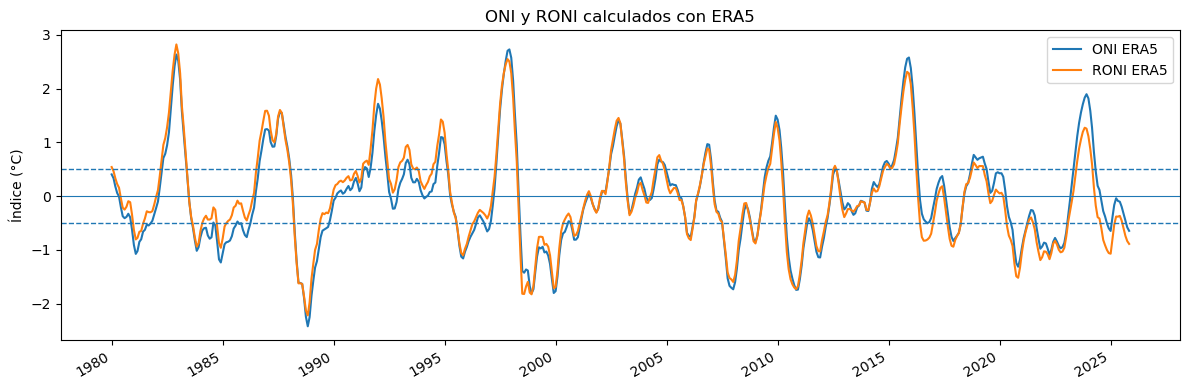

In [ ]:
#Hacemos una gráfica para evaluar visualmente el indice y compararlo con ONI

fig, ax = plt.subplots(figsize=(12, 4))

oni_era5.sel(valid_time=slice(PLOT_START, PLOT_END)).plot(
    ax=ax, label="ONI ERA5"
)

roni_era5.sel(valid_time=slice(PLOT_START, PLOT_END)).plot(
    ax=ax, label="RONI ERA5"
)

ax.axhline(0.5, ls="--", lw=1)
ax.axhline(-0.5, ls="--", lw=1)
ax.axhline(0, lw=0.8)

ax.set_title("ONI y RONI calculados con ERA5")
ax.set_ylabel("Índice (°C)")
ax.set_xlabel("")
ax.legend()

plt.tight_layout()
plt.show()


### ¿Qué estamos buscando corregir o eliminar del índice con el término \(T'_{20S-20N}\)?
## ----------------------------------------------------------------------------------------------------

## Cálculo del SOI

El cálculo del SOI oficial usa observaciones de estación. Aquí calcularemos un **análogo ERA5** usando los puntos de malla más cercanos.

Usaremos los puntos de malla más cercanos a:

- **Tahiti:** $17.65^\circ S,\ 149.57^\circ W$
- **Darwin:** $12.46^\circ S,\ 130.84^\circ E$

1. Calcularemos las anomalías normalizadas de presión para cada mes:

$$
Z=\frac{P-\overline{P}_m}{\sigma_m}.
$$

2. Construimos la serie $D=Z_{Tahiti}-Z_{Darwin}$ siguiendo la formulación descrita por NOAA. Normalizamos esta diferencia por su amplitud RMS durante el período base:

$$
SOI=\frac{D}{\sqrt{\overline{D^2}}}.
$$


In [80]:
#Buscamos los puntos de malla más cercanos a la localización de cada punto
TAHITI_LAT = -17.65
TAHITI_LON = 360 - 149.57   # 210.43 E

DARWIN_LAT = -12.46
DARWIN_LON = 130.84

tahiti = mslp.sel(
    lat=TAHITI_LAT,
    lon=TAHITI_LON,
    method="nearest"
)

darwin = mslp.sel(
    lat=DARWIN_LAT,
    lon=DARWIN_LON,
    method="nearest"
)

print(
    "Punto ERA5 usado para Tahiti:",
    float(tahiti.lat), float(tahiti.lon)
)
print(
    "Punto ERA5 usado para Darwin:",
    float(darwin.lat), float(darwin.lon)
)

Punto ERA5 usado para Tahiti: -17.5 210.0
Punto ERA5 usado para Darwin: -12.5 131.0


In [85]:
#Estandarizamos para el periodo climatológico 1991-2020

z_tahiti = zscore_mens(
    tahiti,
    "valid_time",
    BASE_START,
    BASE_END
)

z_darwin = zscore_mens(
    darwin,
    "valid_time",
    BASE_START,
    BASE_END
)

In [ ]:
#Hacemos el cálculo de D y seleccionamos el periodo base

D = z_tahiti - z_darwin
D_base = D.sel(valid_time=base_slice)

In [88]:
#Calculamos la RMS de D para el periodo base

msd = np.sqrt((D_base**2).mean("valid_time"))

msd

<xarray.DataArray 'msl' ()>
array(1.59706253)

In [89]:
#Finalmente calculamos el SOI

soi_era5 = D /msd
soi_era5.name= "SOI_ERA5"

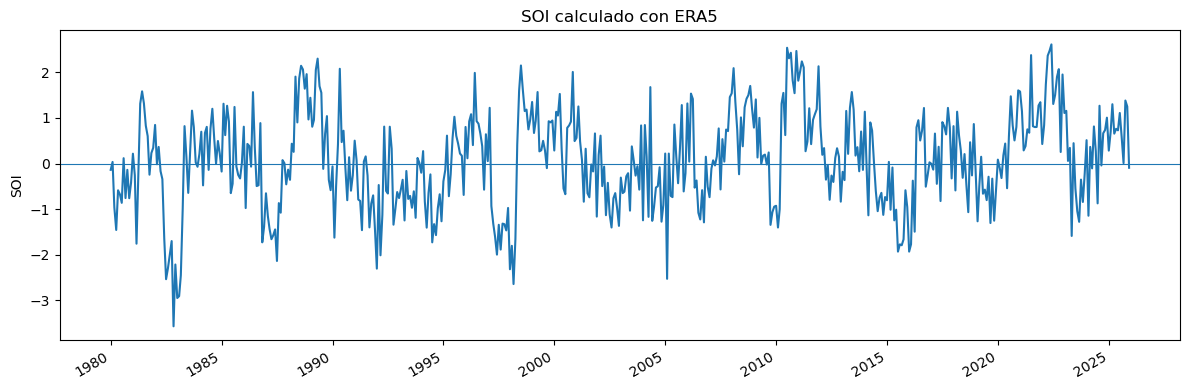

In [91]:
#Generamos una gráfica para poder inspeccionar el SOI

fig, ax = plt.subplots(figsize=(12, 4))

soi_era5.sel(valid_time=slice(PLOT_START, PLOT_END)).plot(ax=ax)

ax.axhline(0, lw=0.8)

ax.set_title("SOI calculado con ERA5")
ax.set_ylabel("SOI")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

# Siguiente clase descargamos los datos de NOAA y comparamos con los cálculos de ERA5